# SVHN Digit Classification: Appendix

This notebook contains the supporting hyperparameter sweeps and alternative approaches referenced from the [main notebook](./main.ipynb). Running it top to bottom doesn't require the main notebook to have been run first, but it does duplicate some setup code (data loading, preprocessing, and the `train_mlp`/`train_cnn` helpers) to make that possible.

**Data requirement:** this notebook expects `train_32x32.mat` and `test_32x32.mat` from the [SVHN site](http://ufldl.stanford.edu/housenumbers/) to be present in `data/`.

## Setup

Imports, data loading, and preprocessing/training helpers, copied from the main notebook so this file runs independently.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from scipy.io import loadmat
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.svm import SVC

In [3]:
training_data = loadmat("data/train_32x32.mat")
testing_data = loadmat("data/test_32x32.mat")

X_tr_raw = training_data['X']
y_tr = training_data['y'].ravel()
X_te_raw = testing_data['X']
y_te = testing_data['y'].ravel()

In [4]:
def greyscale(image):
    """Convert an (H, W, 3, N) RGB image stack to (H, W, N) grayscale using standard luma weights."""
    weights = np.array([0.299, 0.587, 0.114])
    return np.tensordot(image, weights, axes=(2, 0)).astype(np.float64)

X_tr = greyscale(X_tr_raw)
X_te = greyscale(X_te_raw)

# Unflattened image copies for CNN
X_tr_img = np.transpose(X_tr, (2, 0, 1)).copy() 
X_te_img = np.transpose(X_te, (2, 0, 1)).copy()

# Flatten and normalize to [0, 1] for MLP
X_tr_flat = (X_tr.reshape(1024, X_tr.shape[2]) / 255.0).T
X_te_flat = (X_te.reshape(1024, X_te.shape[2]) / 255.0).T

In [4]:
def train_mlp(X_tr, y_tr, X_te, y_te, title, hidden_layer_sizes, n_epochs=100, patience=10, verbose=False):
    mlp = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation='relu',
        solver='adam',
        batch_size=256,
        random_state=123,
    )

    classes = np.unique(y_tr)
    train_accs, test_accs = [], []
    best_test_acc = 0
    epochs_no_improve = 0

    for epoch in range(n_epochs):
        if epoch == 0:
            mlp.partial_fit(X_tr, y_tr, classes=classes)
        else:
            mlp.partial_fit(X_tr, y_tr)
        train_acc = mlp.score(X_tr, y_tr)
        test_acc = mlp.score(X_te, y_te)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        if verbose:
            print(f"Epoch {epoch+1}: train_acc={train_acc:.4f}, test_acc={test_acc:.4f}")

        if test_acc > best_test_acc:
            best_test_acc = test_acc
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
                break

    plt.plot(range(1, len(train_accs) + 1), train_accs, label='Train Accuracy')
    plt.plot(range(1, len(test_accs) + 1), test_accs, label='Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title(f"MLP: {title}")
    plt.show()
    return best_test_acc

PCA-reduced features (needed for the PCA architecture sweep):

In [ ]:
pca = PCA(n_components=0.98)
X_tr_pca = pca.fit_transform(X_tr_flat)
X_te_pca = pca.transform(X_te_flat)

In [5]:
def get_list_or_num_param_val(param, index):
    """Allow a hyperparameter to be given either as a single value (used for every layer)
    or a per-layer list/tuple."""
    if type(param) not in (list, tuple):
        return param
    return param[index] if len(param) > index else param[0]


class SimpleConvNet(torch.nn.Module):
    def __init__(self, numChannels=1, classes=10, channel_sizes=(32, 64), kernel_sizes=((3, 3),),
                 strides=(1,), conv_paddings=(1,), pool_kernels=((2, 2),), pool_strides=(2,),
                 pool_paddings=(0,), fully_connected_features=128, dropout_rate=0.0, device=None, **hyperparameters):
        super().__init__()
        if device is None:
            device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.device = torch.device(device)

        # we store our operations in lists: convolutional layer -> pool -> ...
        self.conv_ = list()
        self.pool_ = list()
        self.drop_ = list()
        for i in range(len(channel_sizes)):
            c = torch.nn.Conv2d(in_channels=numChannels if i == 0 else channel_sizes[i - 1],
                                 out_channels=channel_sizes[i],
                                 kernel_size=get_list_or_num_param_val(kernel_sizes, i),
                                 stride=get_list_or_num_param_val(strides, i),
                                 padding=get_list_or_num_param_val(conv_paddings, i))
            p = torch.nn.MaxPool2d(kernel_size=get_list_or_num_param_val(pool_kernels, i),
                                    stride=get_list_or_num_param_val(pool_strides, i),
                                    padding=get_list_or_num_param_val(pool_paddings, i))
            d = torch.nn.Dropout2d(p=get_list_or_num_param_val(dropout_rate, i))
            self.add_convolution(c, p, d)

        # first fully connected layer - LazyLinear infers correct in_features on first pass
        self.fc1 = torch.nn.LazyLinear(out_features=fully_connected_features)
        self.fc1_drop = torch.nn.Dropout(p=get_list_or_num_param_val(dropout_rate, -1))
        self.fc2 = torch.nn.Linear(in_features=fully_connected_features, out_features=classes)
        self.logSoftmax = torch.nn.LogSoftmax(dim=1)
        self.set_hyperparameters(**hyperparameters)
        self.to(self.device)

    def add_convolution(self, conv, pool, dropout):
        self.conv_.append(conv)
        self.pool_.append(pool)
        self.drop_.append(dropout)
        setattr(self, f"c{len(self.pool_)}", conv)
        setattr(self, f"p{len(self.pool_)}", pool)
        setattr(self, f"d{len(self.pool_)}", dropout)

    def set_hyperparameters(self, learning_rate_init=1e-3, batch_size=64, max_iter=100,
                             momentum=0.9, alpha=.001, activation='relu', **more):
        self.lr = learning_rate_init
        self.batch_size = batch_size
        self.epochs = max_iter
        self.momentum = momentum
        self.alpha = alpha
        # reference: machinelearningmastery.com/activation-functions-in-pytorch/
        if activation == 'relu':
            self.activation_ = torch.nn.ReLU()
        elif activation == 'logistic':
            self.activation_ = torch.nn.Sigmoid()
        elif activation == 'tanh':
            self.activation_ = torch.nn.Tanh()
        elif activation == 'leakyrelu':
            self.activation_ = torch.nn.LeakyReLU()
        else:
            # any other activation function. See: https://pytorch.org/docs/stable/nn.html
            self.activation_ = activation
        if more:
            print("WARNING - unrecognized CNN hyperparameters:", ",".join(more.keys()))
        return self

    def forward(self, X):
        """Compute NN forward pass and output class probabilities (as tensor)."""
        for conv, pool, drop in zip(self.conv_, self.pool_, self.drop_):
            X = drop(pool(self.activation_(conv(X))))
        X_flat = torch.flatten(X, 1)
        X = self.fc1_drop(self.activation_(self.fc1(X_flat)))
        X = self.fc2(X)
        return self.logSoftmax(X)

    def predict_prob(self, X, batch_size=512):
        self.eval()
        X = torch.Tensor(X).unsqueeze(1)
        outputs = []
        with torch.no_grad():
            for i in range(0, X.shape[0], batch_size):
                batch = X[i:i + batch_size].to(self.device)
                outputs.append(self.forward(batch).cpu())
        return torch.cat(outputs, dim=0).numpy()

    def predict(self, X, batch_size=512):
        results = self.predict_prob(X, batch_size=batch_size)
        return np.argmax(results, axis=1)

    def fit(self, X, y, optimizer='adam', X_te=None, y_te=None, early_stopping=False, 
            patience=10, restore_best_weights=True):
        if early_stopping and (X_te is None or y_te is None):
            raise ValueError("early_stopping=True requires X_val and y_val to monitor")

        self.classes_ = np.unique(y)
        self.train_acc_, self.test_acc_ = list(), list()
        lossFn = torch.nn.NLLLoss()
        X = torch.Tensor(X)
        y = torch.Tensor(y).long()
        train_data = torch.utils.data.TensorDataset(X.unsqueeze(1), y)
        trainDataLoader = torch.utils.data.DataLoader(
            train_data, shuffle=True, batch_size=self.batch_size,
            pin_memory=(self.device.type == 'cuda')
        )
        if optimizer == 'adam':
            optimizer = torch.optim.Adam(self.parameters(), lr=self.lr, weight_decay=self.alpha)

        best_test_acc = 0
        best_state = None
        epochs_no_improve = 0

        for epoch in range(self.epochs):
            self.train()
            for (x, y_batch) in trainDataLoader:
                x = x.to(self.device, non_blocking=True)
                y_batch = y_batch.to(self.device, non_blocking=True)
                optimizer.zero_grad()
                pred = self(x)
                loss = lossFn(pred, y_batch)
                loss.backward()
                optimizer.step()

            if X_te is not None and y_te is not None:
                train_pred = self.predict(X.numpy())
                test_pred = self.predict(X_te)
                test_acc = (test_pred == y_te).mean()
                self.train_acc_.append((train_pred == y.numpy()).mean())
                self.test_acc_.append(test_acc)
                
                if early_stopping:
                    if test_acc > best_test_acc:
                        best_test_acc = test_acc
                        epochs_no_improve = 0
                        if restore_best_weights:
                            best_state = {k: v.clone() for k, v in self.state_dict().items()}
                    else:
                        epochs_no_improve += 1
                        if epochs_no_improve >= patience:
                            break

        if early_stopping and restore_best_weights and best_state is not None:
            self.load_state_dict(best_state)


def train_cnn(X_tr, y_tr, X_te, y_te, title, n_epochs=100, patience=10, batch_size=512, device=None, **cnn_kwargs):
    cnn = SimpleConvNet(device=device, max_iter=n_epochs, batch_size=batch_size, **cnn_kwargs)
    cnn.fit(
        X_tr / 255.0, y_tr - 1,
        X_te=X_te / 255.0, y_te=y_te - 1,
        early_stopping=True, patience=patience
    )
    best_test_acc = max(cnn.test_acc_)

    epochs_range = range(1, len(cnn.train_acc_) + 1)
    plt.plot(epochs_range, cnn.train_acc_, label='Train Accuracy')
    plt.plot(epochs_range, cnn.test_acc_, label='Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title(f"CNN: {title}")
    plt.show()

    return best_test_acc

---

### A.1 Preprocessing: Border Width + Interior Margin for Border/Interior Normalization

Sweeps `border_width`/`interior_margin` combinations for `mean_compare` (see main notebook, Section 2) to determine the optimal configuration.

In [ ]:
%%capture
accs = {}
for border, interior in [(1, 1), (1, 2), (1, 4), (1, 8), (1, 12), (2, 2), (2, 4), (2, 8), (2, 12)]:
    X_tr_temp = mean_compare(X_tr, border, interior)
    X_te_temp = mean_compare(X_te, border, interior)
    X_tr_temp = (X_tr_temp.reshape(1024, X_tr_temp.shape[2]) / 255.0).T
    X_te_temp = (X_te_temp.reshape(1024, X_te_temp.shape[2]) / 255.0).T
    acc = train_mlp(X_tr_temp, y_tr, X_te_temp, y_te, "", (128, 64, 32))
    accs[(border, interior)] = acc

In [ ]:
accs

{(1, 1): 0.788759987707437,
 (1, 2): 0.7858789182544561,
 (1, 4): 0.7938306699446834,
 (1, 8): 0.7956745543945912,
 (1, 12): 0.7917562999385371,
 (2, 2): 0.7554548248309773,
 (2, 4): 0.7869161032575291,
 (2, 8): 0.7906038721573448,
 (2, 12): 0.7760064535955746}

### A.2 MLP: Comparing hidden-layer architectures

Four architectures: a deep-and-narrow net, a shallow-and-wide net, a single wide layer, and a shallow-and-wider two-layer net.

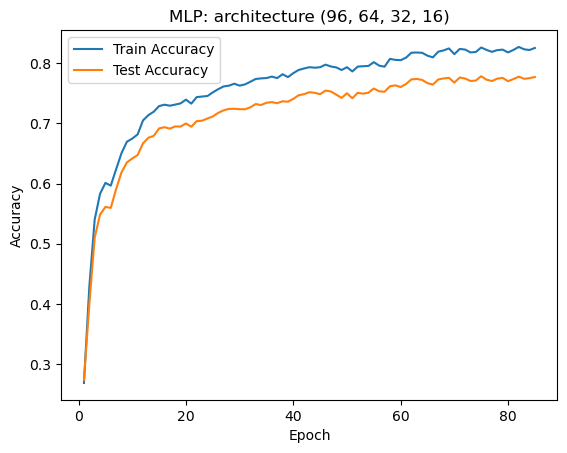

Best test accuracy: 0.7783497234173326


In [ ]:
acc = train_mlp(X_tr_flat, y_tr, X_te_flat, y_te, "architecture (96, 64, 32, 16)", (96, 64, 32, 16))
print("Best test accuracy:", acc)

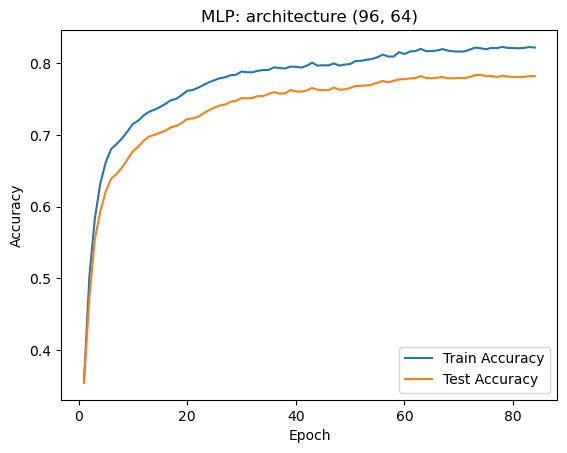

Best test accuracy: 0.7836508912108174


In [ ]:
acc = train_mlp(X_tr_flat, y_tr, X_te_flat, y_te, "architecture (96, 64)", (96, 64))
print("Best test accuracy:", acc)

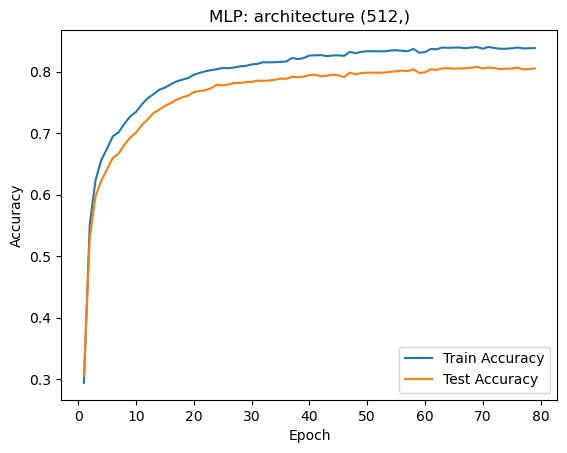

Best test accuracy: 0.8078518746158574


In [ ]:
acc = train_mlp(X_tr_flat, y_tr, X_te_flat, y_te, "architecture (512,)", (512,))
print("Best test accuracy:", acc)

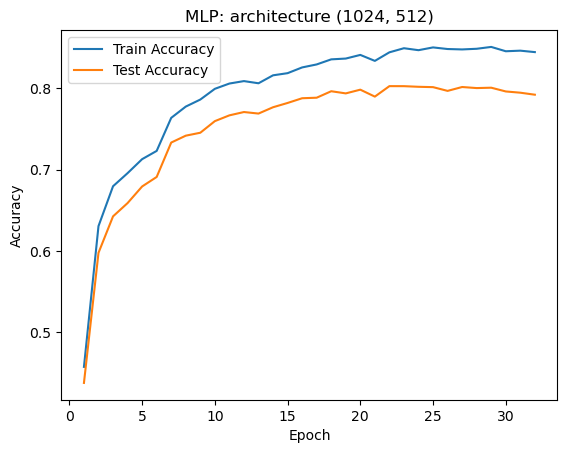

Best test accuracy: 0.8025891210817455


In [ ]:
acc = train_mlp(X_tr_flat, y_tr, X_te_flat, y_te, "architecture (1024, 512)", (1024, 512))
print("Best test accuracy:", acc)

### A.3 Sweeping the PCA variance target

How does test error change as we vary how much variance PCA is allowed to discard?

In [ ]:
%%capture
pca_values = [0.90, 0.95, 0.98, 0.99]
pca_accs = []

for pca_value in pca_values:
    pca = PCA(n_components=pca_value)
    X_tr_temp = pca.fit_transform(X_tr_flat)
    X_te_temp = pca.transform(X_te_flat)
    pca_acc = train_mlp(X_tr_temp, y_tr, X_te_temp, y_te, "", (128, 64))
    pca_accs.append(pca_acc)

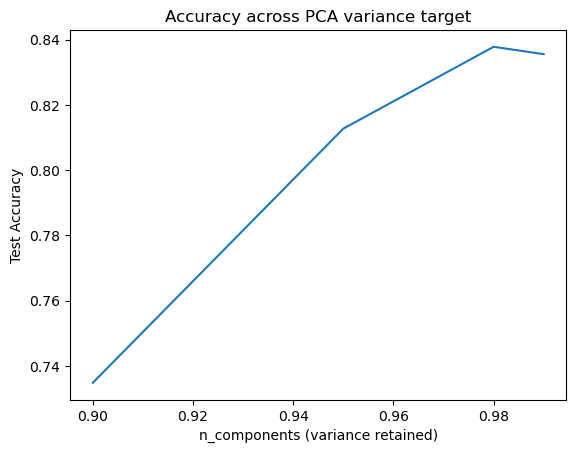

In [ ]:
plt.plot(pca_values, pca_accs)
plt.xlabel('n_components (variance retained)')
plt.ylabel('Test Accuracy')
plt.title('Accuracy across PCA variance target')
plt.show()

### A.4 PCA: Comparing hidden-layer architectures

PCA reduces the input from 1024 raw pixels to a much smaller feature set, so less capacity should be needed to avoid overfitting. Thus, the architectures worth testing here are smaller than the full-pixel sweep above.

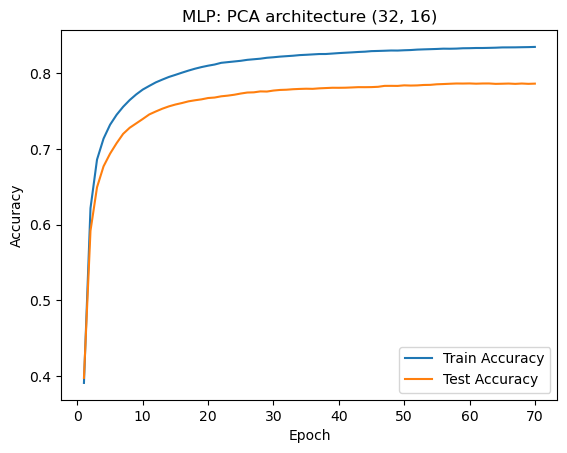

Best test accuracy: 0.7865703749231715


In [ ]:
acc = train_mlp(X_tr_pca, y_tr, X_te_pca, y_te, "PCA architecture (32, 16)", (32, 16))
print("Best test accuracy:", acc)

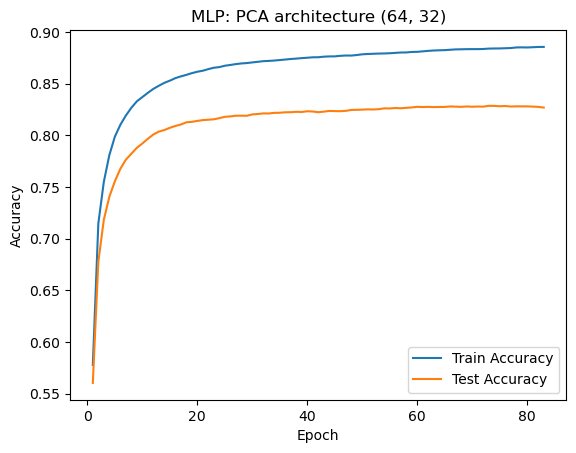

Best test accuracy: 0.828518746158574


In [ ]:
acc = train_mlp(X_tr_pca, y_tr, X_te_pca, y_te, "PCA architecture (64, 32)", (64, 32))
print("Best test accuracy:", acc)

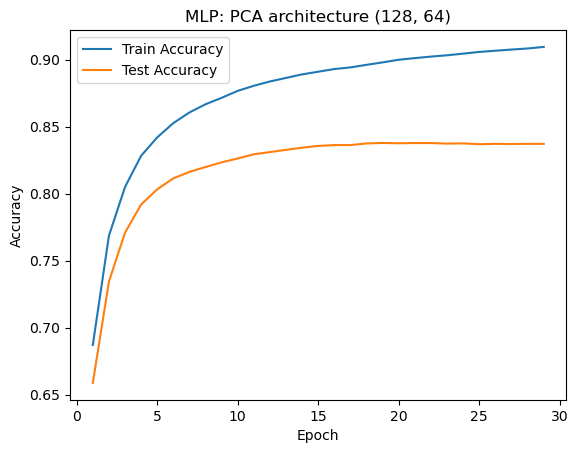

Best test accuracy: 0.8377765826674862


In [ ]:
acc = train_mlp(X_tr_pca, y_tr, X_te_pca, y_te, "PCA architecture (128, 64)", (128, 64))
print("Best test accuracy:", acc)

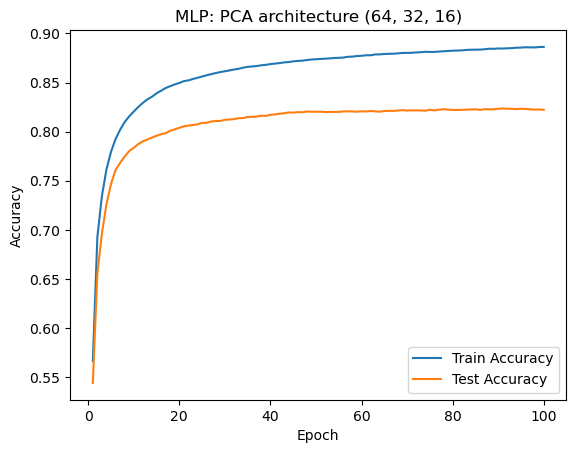

Best test accuracy: 0.8236017209588199


In [ ]:
acc = train_mlp(X_tr_pca, y_tr, X_te_pca, y_te, "PCA architecture (64, 32, 16)", (64, 32, 16))
print("Best test accuracy:", acc)

### A.5 Other Ensemble Configurations

We try two alternatives to the architecture/seed-diverse ensemble used in the main notebook. First, feature-splitting: each sub-model sees only a slice of the PCA-reduced features, and soft voting combines their predictions. We start with 2 MLPs splitting the features in half.

**Result:** This underperformed a single MLP trained on the full feature set. Splitting features reduces the info each sub-model has rather than creating complementary views of the digit.


In [ ]:
select_first_half = FunctionTransformer(lambda X: X[:, :63], validate=False)
select_second_half = FunctionTransformer(lambda X: X[:, 63:], validate=False)

mlp1 = Pipeline([
    ('feature_selector', select_first_half),
    ('mlp', MLPClassifier(hidden_layer_sizes=(32, 64,), activation='relu', batch_size=256, 
                          random_state=1, solver='adam', max_iter=500, alpha=0.01))
])
mlp2 = Pipeline([
    ('feature_selector', select_second_half),
    ('mlp', MLPClassifier(hidden_layer_sizes=(32, 64), activation='relu', batch_size=256, 
                          random_state=2, solver='adam', max_iter=500, alpha=0.01))
])

voting_clf_2 = VotingClassifier(estimators=[('mlp1', mlp1), ('mlp2', mlp2)], voting='soft')
voting_clf_2.fit(X_tr_pca, y_tr)
print("2-way ensemble train accuracy:", voting_clf_2.score(X_tr_pca, y_tr))
print("2-way ensemble test accuracy: ", voting_clf_2.score(X_te_pca, y_te))

2-way ensemble train accuracy: 0.8627571426621347
2-way ensemble test accuracy:  0.8098878303626306


Then, we split the features among 3 MLPs.

In [ ]:
select_1 = FunctionTransformer(lambda X: X[:, :42], validate=False)
select_2 = FunctionTransformer(lambda X: X[:, 42:84], validate=False)
select_3 = FunctionTransformer(lambda X: X[:, 84:], validate=False)

mlp1 = Pipeline([
    ('feature_selector', select_1),
    ('mlp', MLPClassifier(hidden_layer_sizes=(32, 64), activation='relu', batch_size=256, 
                          random_state=1, solver='adam', max_iter=500, alpha=0.01))
])
mlp2 = Pipeline([
    ('feature_selector', select_2),
    ('mlp', MLPClassifier(hidden_layer_sizes=(32, 64), activation='relu', batch_size=256, 
                          random_state=2, solver='adam', max_iter=500, alpha=0.01))
])
mlp3 = Pipeline([
    ('feature_selector', select_3),
    ('mlp', MLPClassifier(hidden_layer_sizes=(32, 64), activation='relu', batch_size=256, 
                          random_state=3, solver='adam', max_iter=500, alpha=0.01))
])

voting_clf_3 = VotingClassifier(estimators=[('mlp1', mlp1), ('mlp2', mlp2), ('mlp3', mlp3)], voting='soft')
voting_clf_3.fit(X_tr_pca, y_tr)
print("3-way ensemble train accuracy:", voting_clf_3.score(X_tr_pca, y_tr))
print("3-way ensemble test accuracy: ", voting_clf_3.score(X_te_pca, y_te))

3-way ensemble train accuracy: 0.8373943786941862
3-way ensemble test accuracy:  0.7931007990165949


Lastly, an ensemble of 3 different model types: MLP, Random Forest Classifier, and Support Vector Classifier, run on a subsample (`n_subsample`) since `SVC(probability=True)` scales poorly with dataset size.

**Result:** The ensemble barely beat its best individual member (the MLP), because the random forest and SVC were considerably weaker on their own.

In [ ]:
n_subsample = 30000
rng = np.random.default_rng(0)
sub_idx = rng.choice(X_tr_pca.shape[0], size=n_subsample, replace=False)
X_tr_pca_sub = X_tr_pca[sub_idx]
y_tr_sub = y_tr[sub_idx]

mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', batch_size=256, 
                    random_state=1, solver='adam', max_iter=500, alpha=0.01)
rf = RandomForestClassifier(n_estimators=200, random_state=1)
svc = SVC(probability=True, random_state=1)

voting_clf_mixed_sub = VotingClassifier(
    estimators=[('mlp', mlp), ('rf', rf), ('svc', svc)],
    voting='soft'
)
voting_clf_mixed_sub.fit(X_tr_pca_sub, y_tr_sub)

print(f"Mixed ensemble (n={n_subsample}) train accuracy:", voting_clf_mixed_sub.score(X_tr_pca_sub, y_tr_sub))
print(f"Mixed ensemble (n={n_subsample}) test accuracy: ", voting_clf_mixed_sub.score(X_te_pca, y_te))

y_te_encoded = voting_clf_mixed_sub.le_.transform(y_te)
for name, model in voting_clf_mixed_sub.named_estimators_.items():
    acc = model.score(X_te_pca, y_te_encoded)
    print(f"{name} test accuracy: {acc:.4f}")

/srv/disk00/caoe5/anaconda/envs/cs178/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Mixed ensemble (n=30000) train accuracy: 0.9817666666666667
Mixed ensemble (n=30000) test accuracy:  0.7836508912108174
mlp test accuracy: 0.7719
rf test accuracy: 0.5719
svc test accuracy: 0.6368


### A.6 CNN: Comparing different channel sizes

Three configurations in which channels grow with depth: two 2-layer options at different widths, and one 3-layer option.


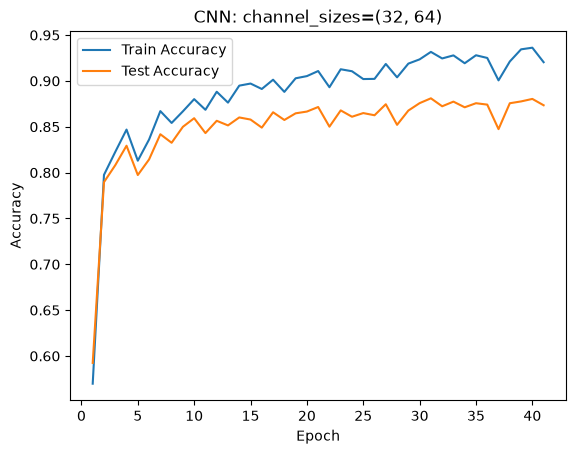

Best test accuracy: 0.8810310387215734


In [9]:
best_acc = train_cnn(X_tr_img, y_tr, X_te_img, y_te, title="channel_sizes=(32, 64)", channel_sizes=(32, 64))
print(f"Best test accuracy: {best_acc}")

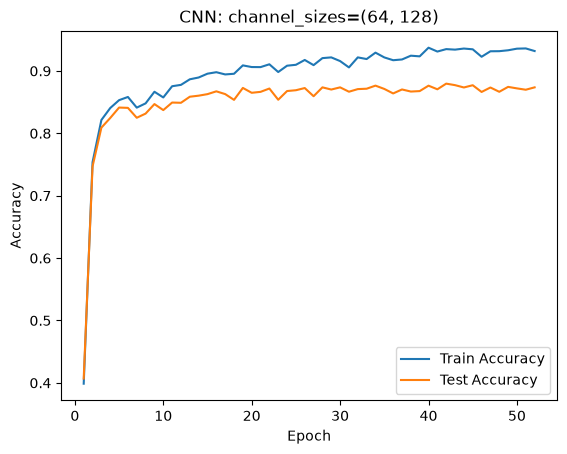

Best test accuracy: 0.8796481253841426


In [8]:
best_acc = train_cnn(X_tr_img, y_tr, X_te_img, y_te, title="channel_sizes=(64, 128)", channel_sizes=(64, 128))
print(f"Best test accuracy: {best_acc}")

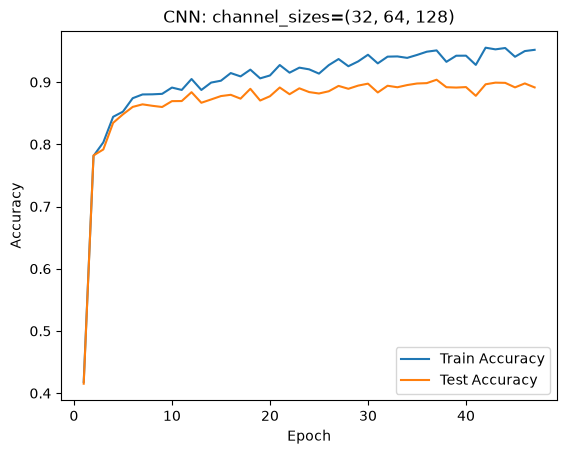

Best test accuracy: 0.9037722802704364


In [ ]:
best_acc = train_cnn(X_tr_img, y_tr, X_te_img, y_te, title="channel_sizes=(32, 64, 128)", channel_sizes=(32, 64, 128))
print(f"Best test accuracy: {best_acc}")

### A.7 CNN: alpha (Weight Decay)

Checks whether L2 regularization via Adam's `weight_decay` (`alpha`, see `SimpleConvNet.fit`) meaningfully closes the train/test accuracy gap seen with larger architectures.

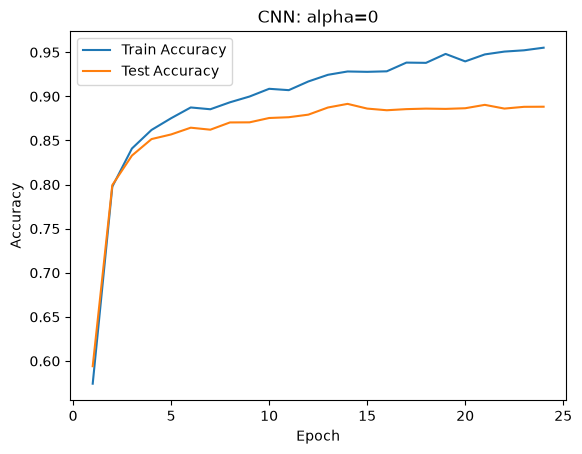

Best test accuracy: 0.8915181315304241


In [ ]:
best_acc = train_cnn(X_tr_img, y_tr, X_te_img, y_te, title="alpha=0", channel_sizes=(32, 64, 128), alpha=0)
print(f"Best test accuracy: {best_acc}")

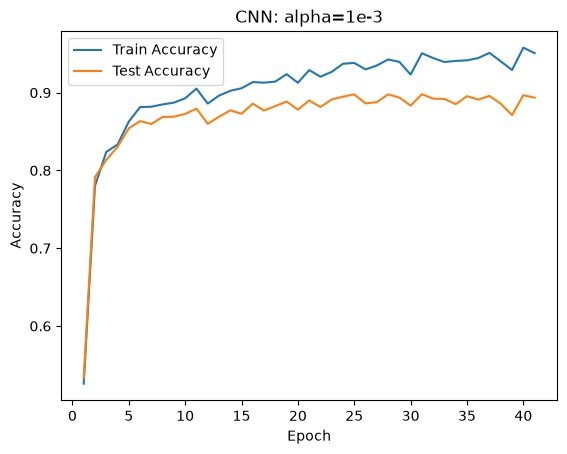

Best test accuracy: 0.8979717271051014


In [ ]:
best_acc = train_cnn(X_tr_img, y_tr, X_te_img, y_te, title="alpha=1e-3", channel_sizes=(32, 64, 128), alpha=1e-3)
print(f"Best test accuracy: {best_acc}")

### A.8 CNN: Dropout Layer(s)

First, we determine the ideal dropout rate.

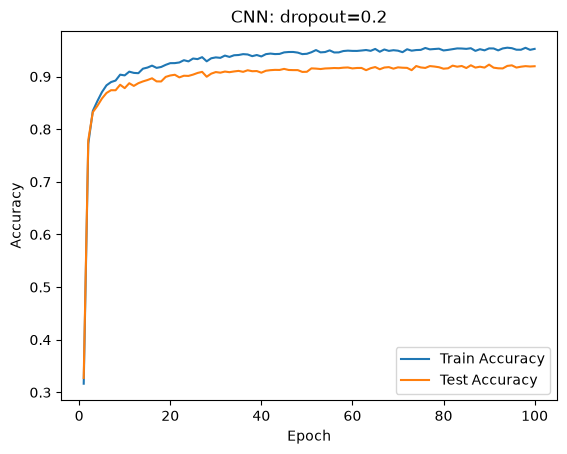

Best test accuracy: 0.9227105101413645


In [5]:
best_acc = train_cnn(X_tr_img, y_tr, X_te_img, y_te, title="dropout=0.2", channel_sizes=(32, 64, 128), dropout_rate=0.2)
print(f"Best test accuracy: {best_acc}")

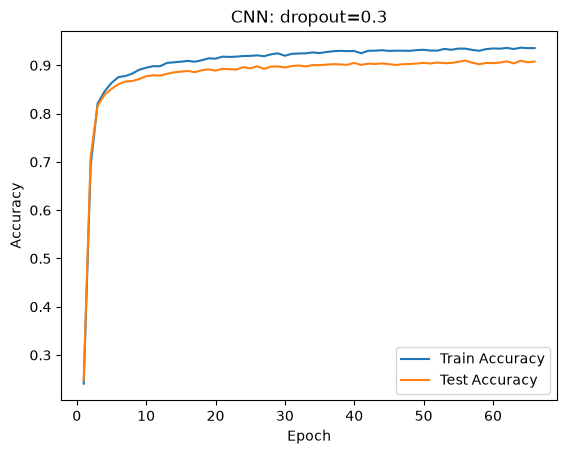

Best test accuracy: 0.9099569760295021


In [6]:
best_acc = train_cnn(X_tr_img, y_tr, X_te_img, y_te, title="dropout=0.3", channel_sizes=(32, 64, 128), dropout_rate=0.3)
print(f"Best test accuracy: {best_acc}")

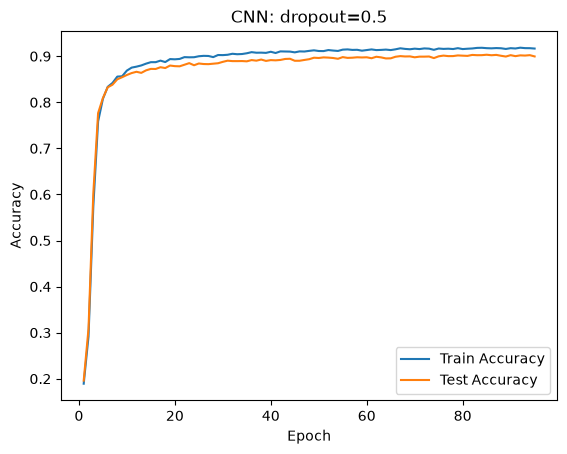

Best test accuracy: 0.9032728948985863


In [7]:
best_acc = train_cnn(X_tr_img, y_tr, X_te_img, y_te, title="dropout=0.5", channel_sizes=(32, 64, 128), dropout_rate=0.5)
print(f"Best test accuracy: {best_acc}")

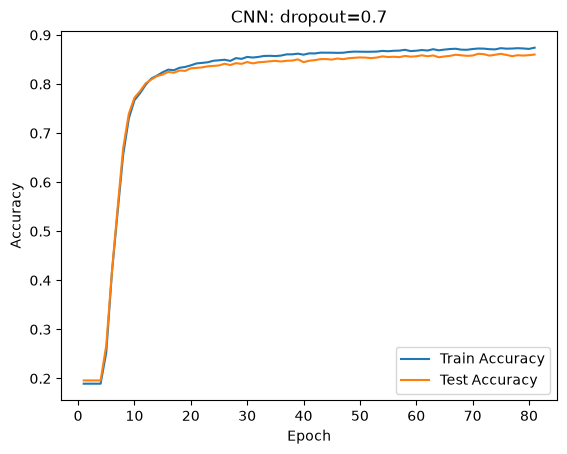

Best test accuracy: 0.8617086662569146


In [8]:
best_acc = train_cnn(X_tr_img, y_tr, X_te_img, y_te, title="dropout=0.7", channel_sizes=(32, 64, 128), dropout_rate=0.7)
print(f"Best test accuracy: {best_acc}")

Next, we determine which layers to apply dropout to.

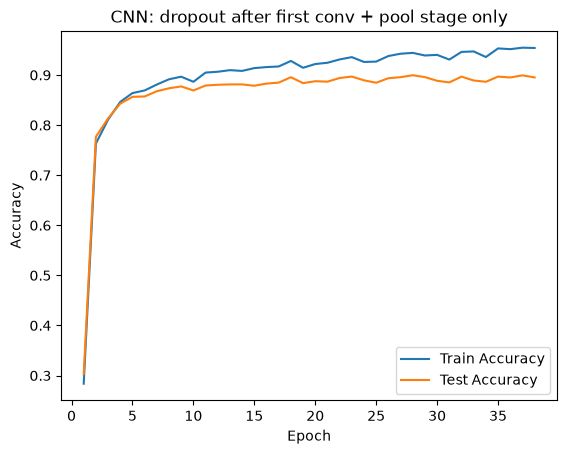

Best test accuracy: 0.8995851259987707


In [9]:
best_acc = train_cnn(X_tr_img, y_tr, X_te_img, y_te, title="dropout after first conv + pool stage only", channel_sizes=(32, 64, 128), dropout_rate=(0.5, 0, 0, 0))
print(f"Best test accuracy: {best_acc}")

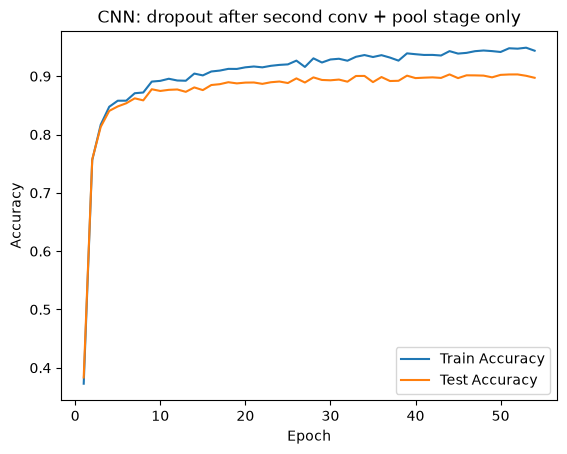

Best test accuracy: 0.9030808236017209


In [10]:
best_acc = train_cnn(X_tr_img, y_tr, X_te_img, y_te, title="dropout after second conv + pool stage only", channel_sizes=(32, 64, 128), dropout_rate=(0, 0.5, 0, 0))
print(f"Best test accuracy: {best_acc}")

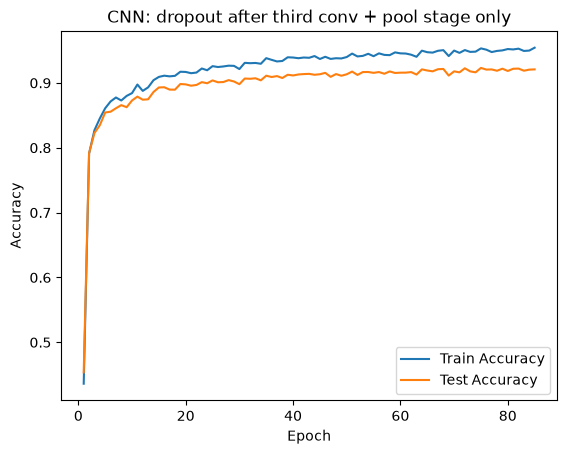

Best test accuracy: 0.9231330669944684


In [11]:
best_acc = train_cnn(X_tr_img, y_tr, X_te_img, y_te, title="dropout after third conv + pool stage only", channel_sizes=(32, 64, 128), dropout_rate=(0, 0, 0.5, 0))
print(f"Best test accuracy: {best_acc}")

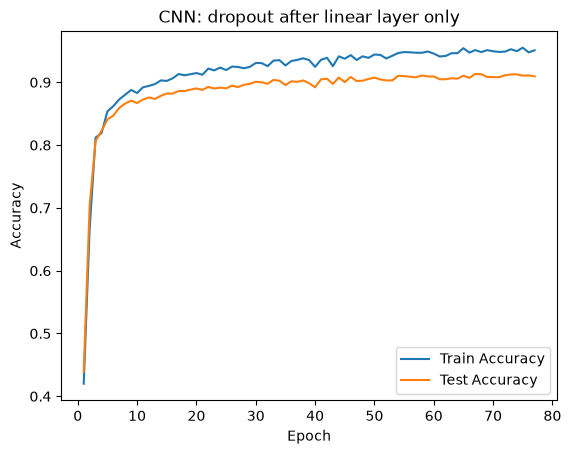

Best test accuracy: 0.9132221880762139


In [12]:
best_acc = train_cnn(X_tr_img, y_tr, X_te_img, y_te, title="dropout after linear layer only", channel_sizes=(32, 64, 128), dropout_rate=(0, 0, 0, 0.5))
print(f"Best test accuracy: {best_acc}")

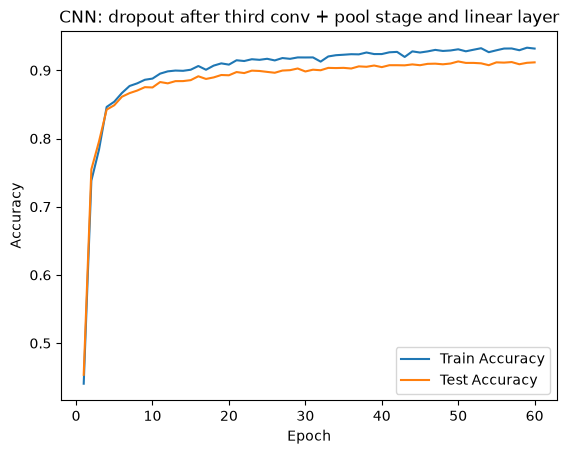

Best test accuracy: 0.9130301167793485


In [7]:
best_acc = train_cnn(X_tr_img, y_tr, X_te_img, y_te, title="dropout after third conv + pool stage and linear layer", channel_sizes=(32, 64, 128), dropout_rate=(0, 0, 0.5, 0.5))
print(f"Best test accuracy: {best_acc}")

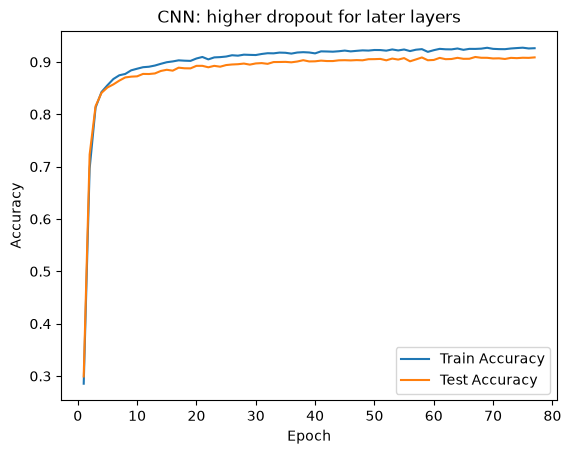

Best test accuracy: 0.9094575906576521


In [13]:
best_acc = train_cnn(X_tr_img, y_tr, X_te_img, y_te, title="higher dropout for later layers", channel_sizes=(32, 64, 128), dropout_rate=(0.2, 0.3, 0.5, 0.5))
print(f"Best test accuracy: {best_acc}")

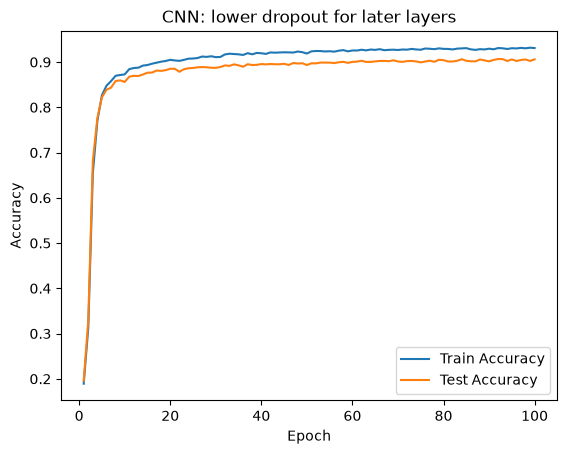

Best test accuracy: 0.9067301782421635


In [14]:
best_acc = train_cnn(X_tr_img, y_tr, X_te_img, y_te, title="lower dropout for later layers", channel_sizes=(32, 64, 128), dropout_rate=(0.5, 0.5, 0.3, 0.2))
print(f"Best test accuracy: {best_acc}")